# Conformer Model - Dataset f08
## 5-Class Speech Emotion Recognition

**Classes:** angry, disgust, fear, sad, neutral

**Dataset:** data_features_f08.csv

In [1]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, cohen_kappa_score
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.layers import (Input, Dense, LayerNormalization, Dropout, 
                                   MultiHeadAttention, Conv1D, GlobalAveragePooling1D)
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.models import Model
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
import warnings
warnings.filterwarnings('ignore')

# Set random seeds
np.random.seed(42)
tf.random.set_seed(42)

print("Libraries imported successfully!")

/Users/giangmytien/Desktop/KLTN/.venv/lib/python3.9/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


Libraries imported successfully!


In [2]:
# Load and explore dataset f08
dataset_path = '../dataset step 2/data_features_f08.csv'
data = pd.read_csv(dataset_path)

print(f"Dataset shape: {data.shape}")
print(f"\nColumns: {data.columns.tolist()}")
print(f"\nLabel distribution:")
print(data['label'].value_counts())
print(f"\nFirst few rows:")
data.head()

Dataset shape: (16120, 53)

Columns: ['0', '1', '2', '3', '4', '5', '6', '7', '8', '9', '10', '11', '12', '13', '14', '15', '16', '17', '18', '19', '20', '21', '22', '23', '24', '25', '26', '27', '28', '29', '30', '31', '32', '33', '34', '35', '36', '37', '38', '39', '40', '41', '42', '43', '44', '45', '46', '47', '48', '49', '50', '51', 'label']

Label distribution:
label
sad        3260
angry      3260
fear       3260
disgust    3260
neutral    3080
Name: count, dtype: int64

First few rows:


,0,1,2,3,4,5,6,7,8,9,...,43,44,45,46,47,48,49,50,51,label
0,0.677892,0.718671,0.702327,0.709592,0.732901,0.733638,0.752644,0.797361,0.822218,0.805413,...,-2.288055,-2.360345,-0.095407,-4.405079,-1.800773,-4.493698,-1.277828,-2.576992,-3.165682,neutral
1,0.703782,0.731340,0.728328,0.738624,0.751419,0.747143,0.775271,0.821946,0.857999,0.876101,...,-2.184267,-1.212305,-0.774240,-1.882376,-2.085121,-2.419807,-2.304472,-1.374303,-1.478163,neutral
2,0.706158,0.709934,0.704273,0.723167,0.742269,0.734252,0.774154,0.814403,0.822734,0.801343,...,-2.291488,-2.326169,-0.134483,-4.450658,-1.788324,-4.499057,-1.280720,-2.582718,-3.205016,neutral
3,0.625470,0.683761,0.728476,0.709726,0.705371,0.717529,0.725345,0.750744,0.795163,0.811719,...,-1.509774,-1.567980,-2.817490,-4.761173,-2.271072,-4.018981,-0.811464,-4.686175,-2.178420,neutral
4,0.654271,0.714414,0.676936,0.636517,0.685949,0.697989,0.731483,0.784736,0.803162,0.756543,...,-1.227616,-1.464897,1.881643,-2.496609,-1.416349,-3.118476,0.819272,-2.767044,-3.644269,neutral


In [3]:
# Data preprocessing
# Filter for 5 classes only
target_classes = ['angry', 'disgust', 'fear', 'sad', 'neutral']
data_filtered = data[data['label'].isin(target_classes)].copy()

print(f"Filtered dataset shape: {data_filtered.shape}")
print(f"\nClass distribution after filtering:")
label_counts = data_filtered['label'].value_counts()
for label, count in label_counts.items():
    percentage = (count / len(data_filtered)) * 100
    print(f"   {label}: {count} samples ({percentage:.1f}%)")

# Prepare features and labels
X = data_filtered.drop('label', axis=1).values
y = data_filtered['label'].values

print(f"\nFeatures shape: {X.shape}")
print(f"Number of features: {X.shape[1]}")

# Encode labels
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

print(f"Classes: {label_encoder.classes_}")
print(f"Number of classes: {len(label_encoder.classes_)}")

Filtered dataset shape: (16120, 53)

Class distribution after filtering:
   sad: 3260 samples (20.2%)
   angry: 3260 samples (20.2%)
   fear: 3260 samples (20.2%)
   disgust: 3260 samples (20.2%)
   neutral: 3080 samples (19.1%)

Features shape: (16120, 52)
Number of features: 52
Classes: ['angry' 'disgust' 'fear' 'neutral' 'sad']
Number of classes: 5


In [4]:
# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)

print(f"Train samples: {X_train.shape[0]}")
print(f"Test samples: {X_test.shape[0]}")

# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Reshape for model input (samples, timesteps, features)
X_train_reshaped = X_train_scaled.reshape(X_train_scaled.shape[0], X_train_scaled.shape[1], 1)
X_test_reshaped = X_test_scaled.reshape(X_test_scaled.shape[0], X_test_scaled.shape[1], 1)

print(f"Reshaped train data: {X_train_reshaped.shape}")
print(f"Reshaped test data: {X_test_reshaped.shape}")

# Convert labels to categorical
y_train_cat = to_categorical(y_train, num_classes=5)
y_test_cat = to_categorical(y_test, num_classes=5)

print(f"Categorical labels shape: {y_train_cat.shape}")

Train samples: 12896
Test samples: 3224
Reshaped train data: (12896, 52, 1)
Reshaped test data: (3224, 52, 1)
Categorical labels shape: (12896, 5)


In [5]:
# Create Conformer model
def create_conformer_block(embed_dim, num_heads, ff_dim, rate=0.1):
    """Create a Conformer block"""
    def conformer_block(inputs):
        # Multi-Head Self Attention
        attn_output = MultiHeadAttention(num_heads=num_heads, key_dim=embed_dim)(inputs, inputs)
        attn_output = Dropout(rate)(attn_output)
        out1 = LayerNormalization(epsilon=1e-6)(inputs + attn_output)
        
        # Convolutional Module
        conv_output = Conv1D(filters=embed_dim, kernel_size=3, padding="same", activation="relu")(out1)
        conv_output = Dropout(rate)(conv_output)
        out2 = LayerNormalization(epsilon=1e-6)(out1 + conv_output)
        
        # Feed Forward Network
        ffn_output = Dense(ff_dim, activation="relu")(out2)
        ffn_output = Dense(embed_dim)(ffn_output)
        ffn_output = Dropout(rate)(ffn_output)
        
        return LayerNormalization(epsilon=1e-6)(out2 + ffn_output)
    
    return conformer_block

def create_conformer_model(input_shape, num_classes=5, embed_dim=64, num_heads=4, ff_dim=128):
    """Create Conformer model for emotion recognition"""
    
    inputs = Input(shape=input_shape)
    
    # Input projection
    x = Dense(embed_dim)(inputs)
    
    # Conformer blocks
    conformer_block = create_conformer_block(embed_dim, num_heads, ff_dim)
    x = conformer_block(x)
    x = conformer_block(x)
    
    # Global pooling
    x = GlobalAveragePooling1D()(x)
    
    # Classification head
    x = Dense(128, activation='relu')(x)
    x = Dropout(0.3)(x)
    x = Dense(64, activation='relu')(x)
    x = Dropout(0.2)(x)
    outputs = Dense(num_classes, activation='softmax')(x)
    
    model = Model(inputs, outputs, name='Conformer_EmotionRecognition')
    return model

# Build model
input_shape = (X_train_reshaped.shape[1], X_train_reshaped.shape[2])
model = create_conformer_model(input_shape)

# Compile model
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print("Conformer model created and compiled!")
model.summary()

Conformer model created and compiled!


Model: "Conformer_EmotionRecognition"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 52, 1)     │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 52, 64)    │        128 │ input_layer[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 52, 64)    │     66,368 │ dense[0][0],      │
│ (MultiHeadAttentio… │                   │            │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 52, 64)    │          0 │ multi_head_atten… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 52, 64)    │          0 │ dense[0][0],      │
│                     │                   │            │ dropout_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalization │ (None, 52, 64)    │        128 │ add[0][0]         │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d (Conv1D)     │ (None, 52, 64)    │     12,352 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_2 (Dropout) │ (None, 52, 64)    │          0 │ conv1d[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_1 (Add)         │ (None, 52, 64)    │          0 │ layer_normalizat… │
│                     │                   │            │ dropout_2[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 52, 64)    │        128 │ add_1[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 52, 128)   │      8,320 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 52, 64)    │      8,256 │ dense_1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_3 (Dropout) │ (None, 52, 64)    │          0 │ dense_2[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_2 (Add)         │ (None, 52, 64)    │          0 │ layer_normalizat… │
│                     │                   │            │ dropout_3[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 52, 64)    │        128 │ add_2[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 52, 64)    │     66,368 │ layer_normalizat… │
│ (MultiHeadAttentio… │                   │            │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_5 (Dropout) │ (None, 52, 64)    │          0 │ multi_head_atten… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_3 (Add)         │ (None, 52, 64)    │          0 │ layer_normalizat… │
│                     │                   │            │ dropout_5[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 52, 64)    │        128 │ add_3[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼─────────────────

 Total params: 208,389 (814.02 KB)

 Trainable params: 208,389 (814.02 KB)

 Non-trainable params: 0 (0.00 B)

In [6]:
# Training
print("Starting training...")

# Callbacks
early_stopping = EarlyStopping(
    monitor='val_accuracy',
    patience=20,
    restore_best_weights=True,
    verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=10,
    min_lr=1e-6,
    verbose=1
)

# Train model
history = model.fit(
    X_train_reshaped, y_train_cat,
    validation_data=(X_test_reshaped, y_test_cat),
    epochs=100,
    batch_size=32,
    callbacks=[early_stopping, reduce_lr],
    verbose=1
)

print("Training completed!")

Starting training...
Epoch 1/100
403/403 ━━━━━━━━━━━━━━━━━━━━ 46s 102ms/step - accuracy: 0.2970 - loss: 1.5322 - val_accuracy: 0.4712 - val_loss: 1.2906 - learning_rate: 0.0010
Epoch 2/100
403/403 ━━━━━━━━━━━━━━━━━━━━ 41s 102ms/step - accuracy: 0.4579 - loss: 1.3117 - val_accuracy: 0.5372 - val_loss: 1.1267 - learning_rate: 0.0010
Epoch 3/100
403/403 ━━━━━━━━━━━━━━━━━━━━ 44s 109ms/step - accuracy: 0.5351 - loss: 1.1448 - val_accuracy: 0.5772 - val_loss: 1.0143 - learning_rate: 0.0010
Epoch 4/100
403/403 ━━━━━━━━━━━━━━━━━━━━ 43s 107ms/step - accuracy: 0.5967 - loss: 0.9935 - val_accuracy: 0.6449 - val_loss: 0.8795 - learning_rate: 0.0010
Epoch 5/100
403/403 ━━━━━━━━━━━━━━━━━━━━ 43s 108ms/step - accuracy: 0.6471 - loss: 0.8825 - val_accuracy: 0.6842 - val_loss: 0.7901 - learning_rate: 0.0010
Epoch 6/100
403/403 ━━━━━━━━━━━━━━━━━━━━ 45s 111ms/step - accuracy: 0.6701 - loss: 0.8278 - val_accuracy: 0.7053 - val_loss: 0.7056 - learning_rate: 0.0010
Epoch 7/100
403/403 ━━━━━━━━━━━━━━━━━━━━ 45

In [7]:
# Evaluation and Results
print("CONFORMER MODEL EVALUATION - Dataset f08")
print("=" * 60)

# Predictions
y_pred_prob = model.predict(X_test_reshaped, verbose=0)
y_pred = np.argmax(y_pred_prob, axis=1)

# Test accuracy
test_loss, test_accuracy = model.evaluate(X_test_reshaped, y_test_cat, verbose=0)
print(f"Test Accuracy: {test_accuracy:.4f}")
print(f"Test Loss: {test_loss:.4f}")

# Classification Report
print(f"\nCLASSIFICATION REPORT:")
print("-" * 50)
class_names = label_encoder.classes_
report = classification_report(y_test, y_pred, target_names=class_names, digits=4)
print(report)

# Cohen's Kappa
kappa = cohen_kappa_score(y_test, y_pred)
print(f"\nCohen's Kappa Score: {kappa:.4f}")

# Training Summary
epochs_trained = len(history.history['accuracy'])
final_train_acc = history.history['accuracy'][-1]
final_val_acc = history.history['val_accuracy'][-1]

print(f"\nTRAINING SUMMARY:")
print("-" * 50)
print(f"Final Training Accuracy: {final_train_acc:.4f}")
print(f"Final Validation Accuracy: {final_val_acc:.4f}")
print(f"Epochs Trained: {epochs_trained}")

CONFORMER MODEL EVALUATION - Dataset f08
Test Accuracy: 0.8952
Test Loss: 0.3019

CLASSIFICATION REPORT:
--------------------------------------------------
              precision    recall  f1-score   support

       angry     0.9349    0.9034    0.9189       652
     disgust     0.8754    0.9049    0.8899       652
        fear     0.9131    0.8865    0.8996       652
     neutral     0.9252    0.8831    0.9037       616
         sad     0.8369    0.8972    0.8660       652

    accuracy                         0.8952      3224
   macro avg     0.8971    0.8950    0.8956      3224
weighted avg     0.8968    0.8952    0.8955      3224


Cohen's Kappa Score: 0.8689

TRAINING SUMMARY:
--------------------------------------------------
Final Training Accuracy: 0.9255
Final Validation Accuracy: 0.8846
Epochs Trained: 100



CONFUSION MATRIX:
--------------------------------------------------
Predicted ->
True    angry     disgust   fear      neutral   sad       
angry   589       27        21        1         14        
disgust 12        590       15        13        22        
fear    21        19        578       8         26        
neutral 1         14        5         544       52        
sad     7         24        14        22        585       


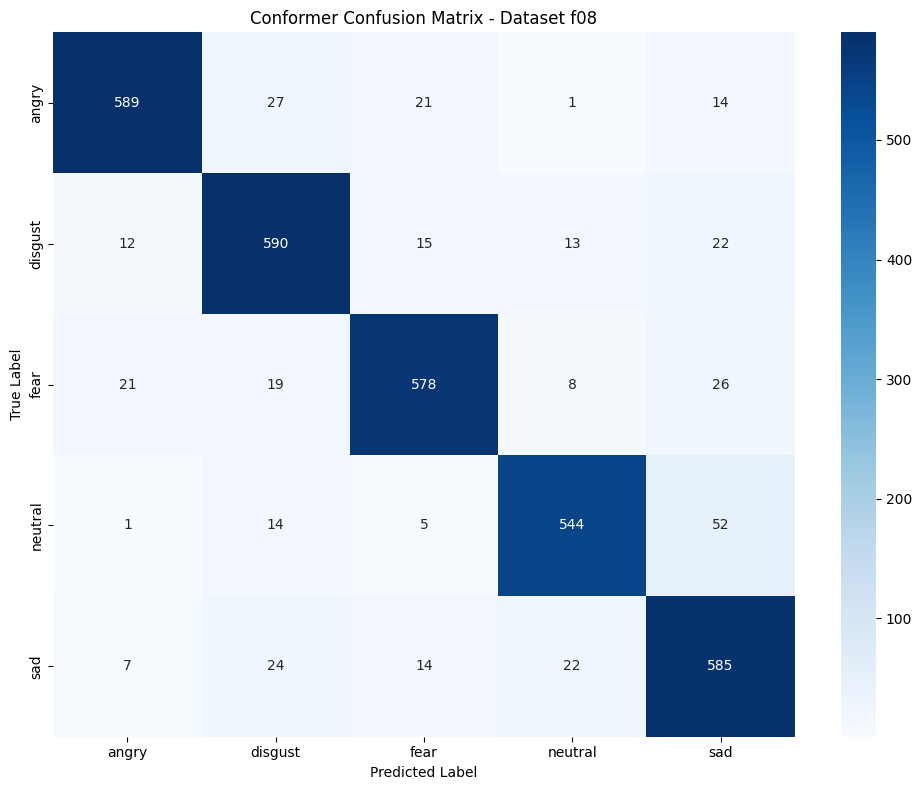

In [8]:
# Confusion Matrix
print(f"\nCONFUSION MATRIX:")
print("-" * 50)
cm = confusion_matrix(y_test, y_pred)

# Print confusion matrix in text format
print("Predicted ->")
print(f"{'True':<8}", end="")
for class_name in class_names:
    print(f"{class_name:<10}", end="")
print()

for i, class_name in enumerate(class_names):
    print(f"{class_name:<8}", end="")
    for j in range(len(class_names)):
        print(f"{cm[i,j]:<10}", end="")
    print()

# Visualize Confusion Matrix
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names,
            yticklabels=class_names)
plt.title('Conformer Confusion Matrix - Dataset f08')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.tight_layout()
plt.show()

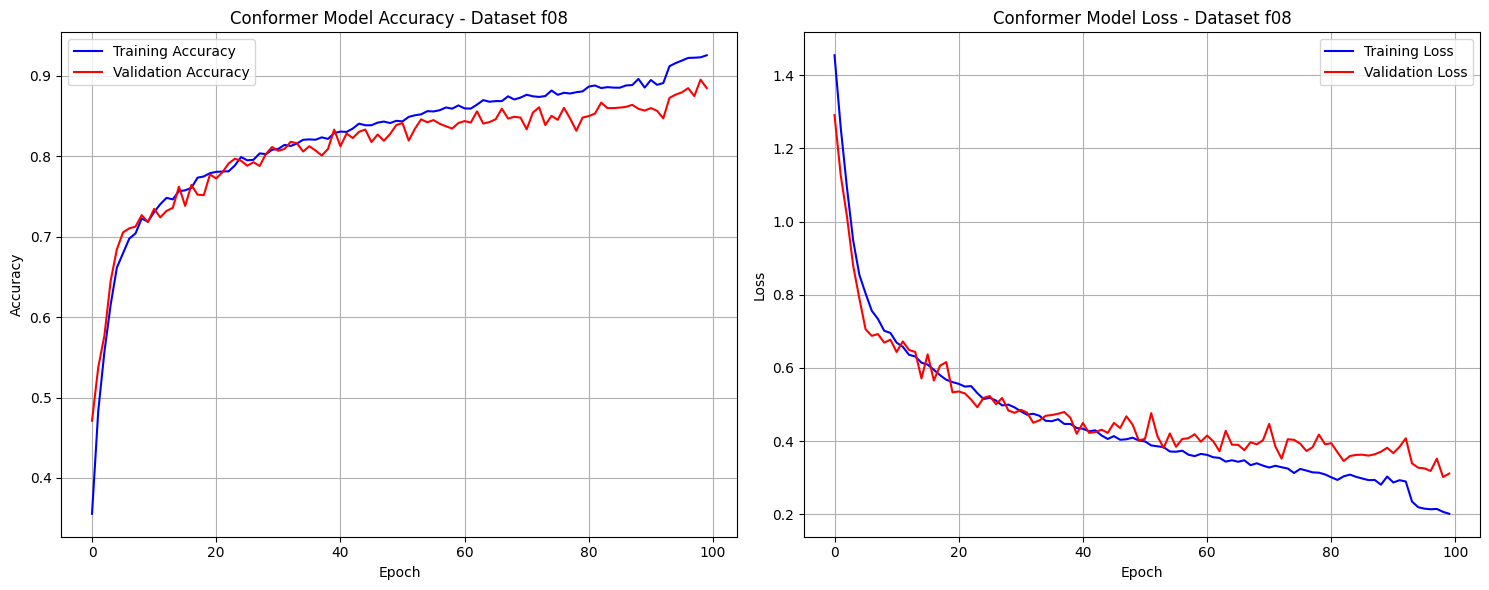

Training history plots generated!


In [9]:
# Plot Training History
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# Accuracy plot
ax1.plot(history.history['accuracy'], label='Training Accuracy', color='blue')
ax1.plot(history.history['val_accuracy'], label='Validation Accuracy', color='red')
ax1.set_title('Conformer Model Accuracy - Dataset f08')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Accuracy')
ax1.legend()
ax1.grid(True)

# Loss plot
ax2.plot(history.history['loss'], label='Training Loss', color='blue')
ax2.plot(history.history['val_loss'], label='Validation Loss', color='red')
ax2.set_title('Conformer Model Loss - Dataset f08')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Loss')
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.show()

print("Training history plots generated!")

In [ ]:
# Final summary
print(f"\nFINAL RESULTS SUMMARY - Conformer f08")
print("=" * 60)
print(f"Test Accuracy: {test_accuracy:.4f}")
print(f"Cohen's Kappa: {kappa:.4f}")
print(f"Epochs Trained: {epochs_trained}")
print(f"Dataset: data_features_f08.csv")
print(f"Classes: {', '.join(class_names)}")


FINAL RESULTS SUMMARY - Conformer f08
Test Accuracy: 0.8952
Cohen's Kappa: 0.8689
Epochs Trained: 100
Dataset: data_features_f08.csv
Classes: angry, disgust, fear, neutral, sad


: 